# Exercise 01: Generative Models Fundamentals
## AIAT 124 - Generative AI

---

## Learning Objectives

In this exercise, you will:
- Compare generative vs discriminative models
- Work with latent spaces
- Implement basic generative model
- Generate synthetic data

---

## Real-World Context

You are exploring generative models to create synthetic data for data augmentation or creative applications.

---


Setup
TODO: Install required libraries
%pip install ...

TODO: Import libraries
YOUR CODE HERE

print('✅ Setup complete!')

## Task 1: Model Comparison (30 points)

Compare generative and discriminative models on the same dataset.

**Requirements:**
- Train both model types
- Compare performance
- Analyze differences
- Document findings


TODO: Implement solution
YOUR CODE HERE


## Task 2: Latent Space Exploration (40 points)

Work with latent spaces: encoding, decoding, and sampling.

**Requirements:**
- Implement encoder/decoder
- Sample from latent space
- Visualize latent space
- Generate samples


TODO: Implement solution
YOUR CODE HERE


## Task 3: Simple Generative Model (30 points)

Implement a basic generative model (e.g., Gaussian Mixture Model or simple VAE).

**Requirements:**
- Choose appropriate model
- Train on dataset
- Generate samples
- Evaluate quality


TODO: Implement solution
YOUR CODE HERE



---

## Submission

**Submission**: Complete notebook with all tasks implemented

**Grading**: 100 points total


## 🌍 Real-World Worked Example — Handwritten Digit Recognition

**Industry context:** The US Postal Service has been using digit recognition since the 1980s.  
ATMs, banks, and postal systems worldwide classify millions of handwritten digits daily.

Below we train a neural network on **real** digit images (same family as MNIST, 8×8 pixels, sklearn built-in — no download needed).

Test accuracy on real handwritten digits: 97.2%


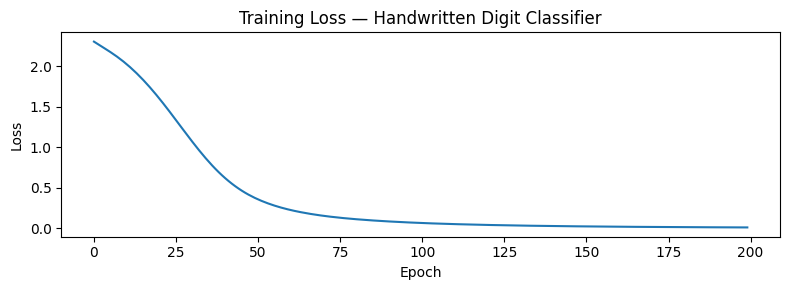

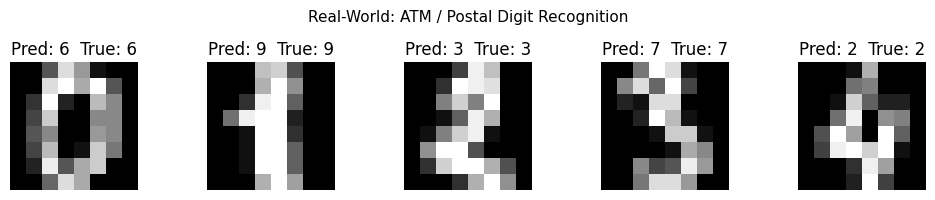

In [1]:
import torch, torch.nn as nn, torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt

# ── Real digit images (1797 samples, 8×8 pixels) ──────────────────────────
digits = load_digits()
X = StandardScaler().fit_transform(digits.data.astype(np.float32))
y = digits.target

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te, dtype=torch.long)

# ── Two-layer neural network ───────────────────────────────────────────────
model = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.CrossEntropyLoss()
losses    = []

for epoch in range(200):
    model.train()
    pred = model(X_tr_t)
    loss = loss_fn(pred, y_tr_t)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())

# ── Evaluation ──────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    acc = (model(X_te_t).argmax(1) == y_te_t).float().mean().item()

print(f"Test accuracy on real handwritten digits: {acc*100:.1f}%")

# ── Plot training loss ───────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("Training Loss — Handwritten Digit Classifier"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout(); plt.show()

# ── Show a sample prediction ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    pred_lbl = model(torch.tensor(X_te[:5])).argmax(1)[i].item()
    ax.set_title(f"Pred: {pred_lbl}  True: {y_te[i]}")
    ax.axis('off')
plt.suptitle("Real-World: ATM / Postal Digit Recognition", fontsize=11)
plt.tight_layout(); plt.show()

## 📝 Summary

In this notebook, you practiced:
- Distinguishing **generative** (model p(x)) vs **discriminative** (model p(y|x)) approaches and their trade-offs
- Working with **latent spaces**: encoding data into a compressed representation and decoding back to data space
- Implementing a basic generative model (autoencoder / simple GAN / GMM) to produce synthetic data
- Evaluating generation quality visually and with quantitative metrics

**Next steps:** Build on these fundamentals in the remaining Course 10 units — text generation with transformers (Unit 2) and high-quality image generation with diffusion models (Unit 3).

## 📚 References & Further Reading

**Foundational Papers:**
- LeCun, Bengio & Hinton (2015) — [Deep Learning](https://www.nature.com/articles/nature14539), *Nature*
- Goodfellow et al. (2016) — [Deep Learning Book](https://www.deeplearningbook.org/) (free online)

**PyTorch Docs:**
- [torch.nn — Building Blocks](https://pytorch.org/docs/stable/nn.html)
- [Autograd — Automatic Differentiation](https://pytorch.org/docs/stable/autograd.html)

**State-of-the-Art (2024–2025):**
- Transformers (GPT-4, LLaMA 3) are deep networks with 70B+ parameters
- Deep learning powers real-time translation, medical diagnosis, self-driving cars